In [1]:
# --- 1. Imports and Environment Setup ---
import torch, gc
import numpy as np
import random
import matplotlib.pyplot as plt

# Auto-reload external modules
%load_ext autoreload
%autoreload 2

# Import our custom classes
from pinn_model import PINN
from pinn_solver import PINNSolver


In [3]:
# --- 2. Reproducibility and Global Setup ---
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

K = 100.0
r = 0.05
T = 1.0


Using device: cuda


In [4]:
# --- 3. Train the Prerequisite "Generalist" Pricing Engine ---
print("--- Training the Generalist European Solver (Prerequisite for Calibration) ---")

generalist_model = PINN().to(device)
pricing_solver = PINNSolver(generalist_model, K=K, r=r, T=T, s_max_multiplier=4.0)

epochs = 20000 

loss_history = pricing_solver.train(
    epochs=epochs, n_pde=5000, n_boundary=1000, n_terminal=1000,
    option_type='call',
    sobol_phase_epochs=8000,    
    is_american=False
)
print("Training complete. Pricing engine is ready.")

--- Training the Generalist European Solver (Prerequisite for Calibration) ---
Epoch 0/20000 [Sobol] Loss: 8.092277 (PDE: 0.001224, BC: 0.809105)
Epoch 1000/20000 [Sobol] Loss: 0.000595 (PDE: 0.000342, BC: 0.000025)
Epoch 2000/20000 [Sobol] Loss: 0.000273 (PDE: 0.000149, BC: 0.000012)
Epoch 3000/20000 [Sobol] Loss: 0.000157 (PDE: 0.000073, BC: 0.000008)
Epoch 4000/20000 [Sobol] Loss: 0.000131 (PDE: 0.000057, BC: 0.000007)
Epoch 5000/20000 [Sobol] Loss: 0.000089 (PDE: 0.000045, BC: 0.000004)
Epoch 6000/20000 [Sobol] Loss: 0.000062 (PDE: 0.000028, BC: 0.000003)
Epoch 7000/20000 [Sobol] Loss: 0.000085 (PDE: 0.000051, BC: 0.000003)
--- Epoch 8000: Adaptive Resampling ---
Epoch 8000/20000 [Adaptive] Loss: 0.000722 (PDE: 0.000174, BC: 0.000055)
--- Epoch 8200: Adaptive Resampling ---
--- Epoch 8400: Adaptive Resampling ---
--- Epoch 8600: Adaptive Resampling ---
--- Epoch 8800: Adaptive Resampling ---
--- Epoch 9000: Adaptive Resampling ---
Epoch 9000/20000 [Adaptive] Loss: 0.000247 (PDE: 0.

In [11]:
K = 100.0
r = 0.05
T_max = 2.0

from surface_pinn_solver import SurfacePINNSolver
surface_solver = SurfacePINNSolver(generalist_model, K=K, r=r, T=T_max)

In [12]:
moneyness = np.linspace(0.8, 1.2, 30) 
maturities = np.linspace(0.1, 2.0, 30)

M_grid, Tau_grid = np.meshgrid(moneyness, maturities)
S_grid = M_grid * K           # Convert Moneyness back to Stock Price
t_grid = T_max - Tau_grid     # Convert TTM to time t

# Flatten for batch processing
S_flat = torch.tensor(S_grid.flatten(), dtype=torch.float32).view(-1, 1)
t_flat = torch.tensor(t_grid.flatten(), dtype=torch.float32).view(-1, 1)


In [13]:
M_flat = S_flat / K
Tau_flat = T_max - t_flat

# Formula: Volatility is higher at low strikes (skew) and short maturities
sigma_true = 0.3 + 0.4 * (M_flat - 1.0)**2 + 0.05 * torch.exp(-Tau_flat)

# Calculate BS Price using PyTorch Distributions (Analytical)
def black_scholes_torch(S, K, T, r, sigma, t):
    tau = T - t
    d1 = (torch.log(S/K) + (r + 0.5 * sigma**2) * tau) / (sigma * torch.sqrt(tau))
    d2 = d1 - sigma * torch.sqrt(tau)
    N = torch.distributions.Normal(0, 1)
    # Call Price
    return S * N.cdf(d1) - K * torch.exp(-r * tau) * N.cdf(d2)

# Generate "Market" Prices
V_market_flat = black_scholes_torch(S_flat, K, T_max, r, sigma_true, t_flat)

# Pack data
surface_data = {'S': S_flat, 't': t_flat, 'V': V_market_flat}

In [14]:
iv_flat = surface_solver.calibrate_surface(surface_data, epochs=5000, learning_rate=0.05)

# Reshape
iv_surface = iv_flat.reshape(M_grid.shape)
true_surface = sigma_true.numpy().reshape(M_grid.shape)

--- Calibrating Surface (Stabilized) | Reg=0.1 | LR=0.05 ---
Ep 0: Fit 135.807266 | Smooth 0.000000 | Vol 0.30
Ep 500: Fit 0.000032 | Smooth 0.003530 | Vol 0.53
Ep 1000: Fit 0.000017 | Smooth 0.003446 | Vol 0.53
Ep 1500: Fit 0.000004 | Smooth 0.003311 | Vol 0.53
Ep 2000: Fit 0.000002 | Smooth 0.003300 | Vol 0.53
Ep 2500: Fit 0.000002 | Smooth 0.003281 | Vol 0.53
Ep 3000: Fit 0.000002 | Smooth 0.003272 | Vol 0.53
Ep 3500: Fit 0.000002 | Smooth 0.003266 | Vol 0.53
Ep 4000: Fit 0.000002 | Smooth 0.003267 | Vol 0.53
Ep 4500: Fit 0.000002 | Smooth 0.003264 | Vol 0.53


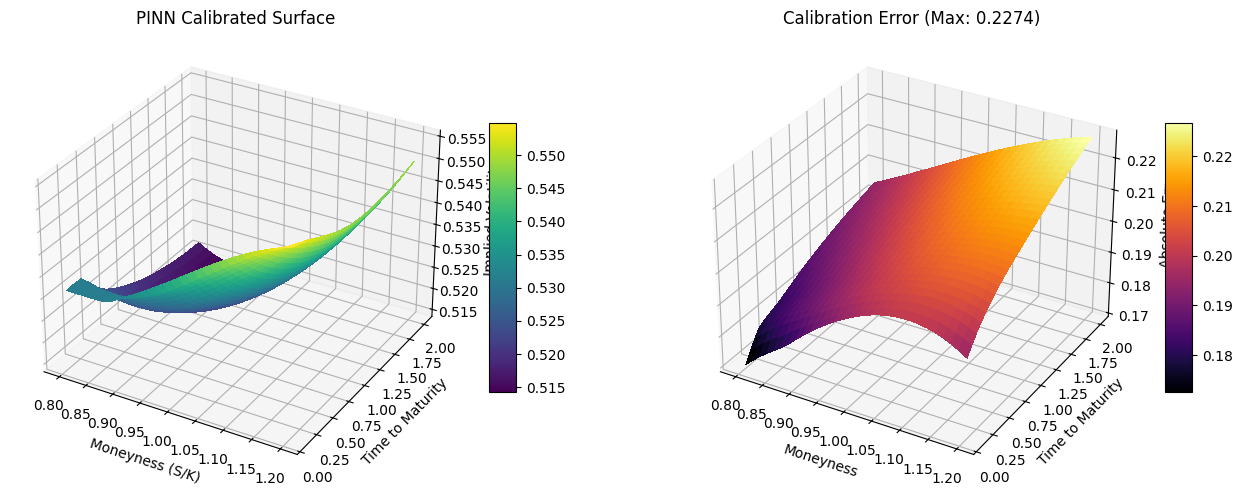

In [15]:
from matplotlib import cm
fig = plt.figure(figsize=(16, 7))

# Plot 1: The PINN Recovered Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(M_grid, Tau_grid, iv_surface, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_xlabel('Moneyness (S/K)')
ax1.set_ylabel('Time to Maturity')
ax1.set_zlabel('Implied Volatility')
ax1.set_title('PINN Calibrated Surface')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Plot 2: The Error (Difference from Truth)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
error = np.abs(iv_surface - true_surface)
surf2 = ax2.plot_surface(M_grid, Tau_grid, error, cmap=cm.inferno, linewidth=0, antialiased=False)
ax2.set_xlabel('Moneyness')
ax2.set_ylabel('Time to Maturity')
ax2.set_zlabel('Absolute Error')
ax2.set_title(f'Calibration Error (Max: {np.max(error):.4f})')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.show()

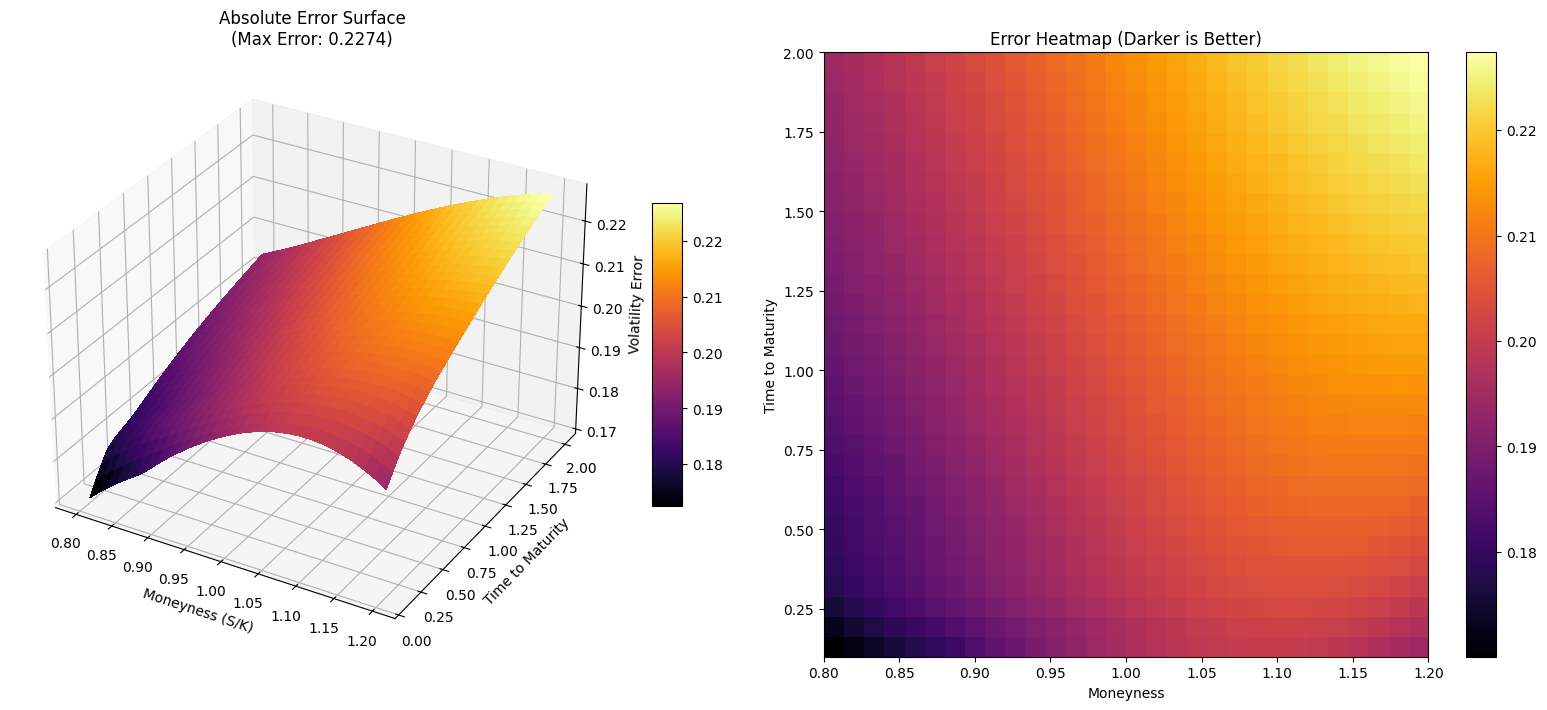

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch

# --- 1. Setup Parameters (Must match your calibration) ---
K = 100.0
r = 0.05
T_max = 2.0
grid_resolution = 30

# --- 2. Reconstruct the Grid ---
moneyness = np.linspace(0.8, 1.2, grid_resolution)
maturities = np.linspace(0.1, 2.0, grid_resolution)
M_grid, Tau_grid = np.meshgrid(moneyness, maturities)

S_grid = M_grid * K
t_grid = T_max - Tau_grid 

# --- 3. Define the Ground Truth (The "Smile" Formula) ---
# This MUST match the formula you used to generate the training data
# (If you used constant sigma=0.5, change this line to: sigma_true = np.full_like(M_grid, 0.5))
sigma_true = 0.3 + 0.4 * (M_grid - 1.0)**2 + 0.05 * np.exp(-Tau_grid)

# --- 4. Get Your Calibrated Surface ---
# Assuming 'iv_surface' is the variable holding your result from the previous step.
# If you haven't saved it, re-run calibration or use the variable currently in memory.
# iv_surface = ... (your result from surface_solver.calibrate_surface)

# Error Calculation
absolute_error = np.abs(iv_surface - sigma_true)
percentage_error = absolute_error / sigma_true * 100

# --- 5. Plot the Error Surface ---
fig = plt.figure(figsize=(16, 7))

# Plot A: Absolute Error
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(M_grid, Tau_grid, absolute_error, cmap=cm.inferno, linewidth=0, antialiased=False)
ax1.set_xlabel('Moneyness (S/K)')
ax1.set_ylabel('Time to Maturity')
ax1.set_zlabel('Volatility Error')
ax1.set_title(f'Absolute Error Surface\n(Max Error: {np.max(absolute_error):.4f})')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Plot B: 2D Heatmap (Easier to see hotspots)
ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(absolute_error, extent=[0.8, 1.2, 0.1, 2.0], origin='lower', aspect='auto', cmap=cm.inferno)
ax2.set_xlabel('Moneyness')
ax2.set_ylabel('Time to Maturity')
ax2.set_title('Error Heatmap (Darker is Better)')
fig.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

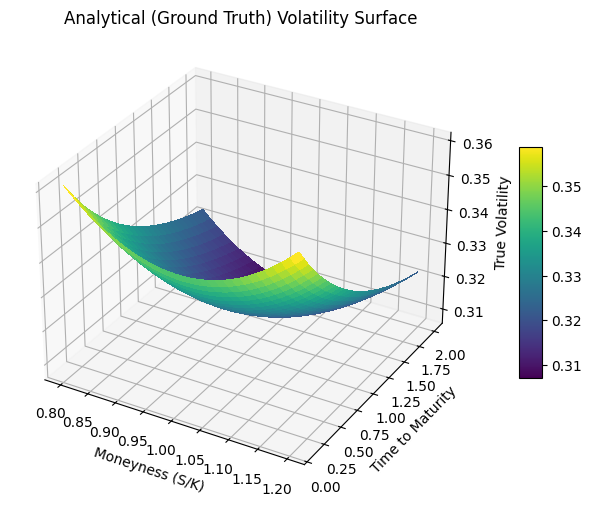

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch

# --- 1. Define the Grid ---
moneyness = np.linspace(0.8, 1.2, 30)
maturities = np.linspace(0.1, 2.0, 30)
M_grid, Tau_grid = np.meshgrid(moneyness, maturities)

# --- 2. Define the Synthetic "True" Volatility Function ---
# This matches the formula provided in the previous solution
# Sigma = 0.3 + 0.4 * (M-1)^2 + 0.05 * exp(-tau)
sigma_true = 0.3 + 0.4 * (M_grid - 1.0)**2 + 0.05 * np.exp(-Tau_grid)

# --- 3. Plotting ---
fig = plt.figure(figsize=(12, 6))

# Plot: The Analytical "True" Surface
ax = fig.add_subplot(1, 1, 1, projection='3d')
surf = ax.plot_surface(M_grid, Tau_grid, sigma_true, cmap=cm.viridis, linewidth=0, antialiased=False)

ax.set_xlabel('Moneyness (S/K)')
ax.set_ylabel('Time to Maturity')
ax.set_zlabel('True Volatility')
ax.set_title('Analytical (Ground Truth) Volatility Surface')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.show()

--- Generating Plot 1: Analytical Vega Heatmap ---


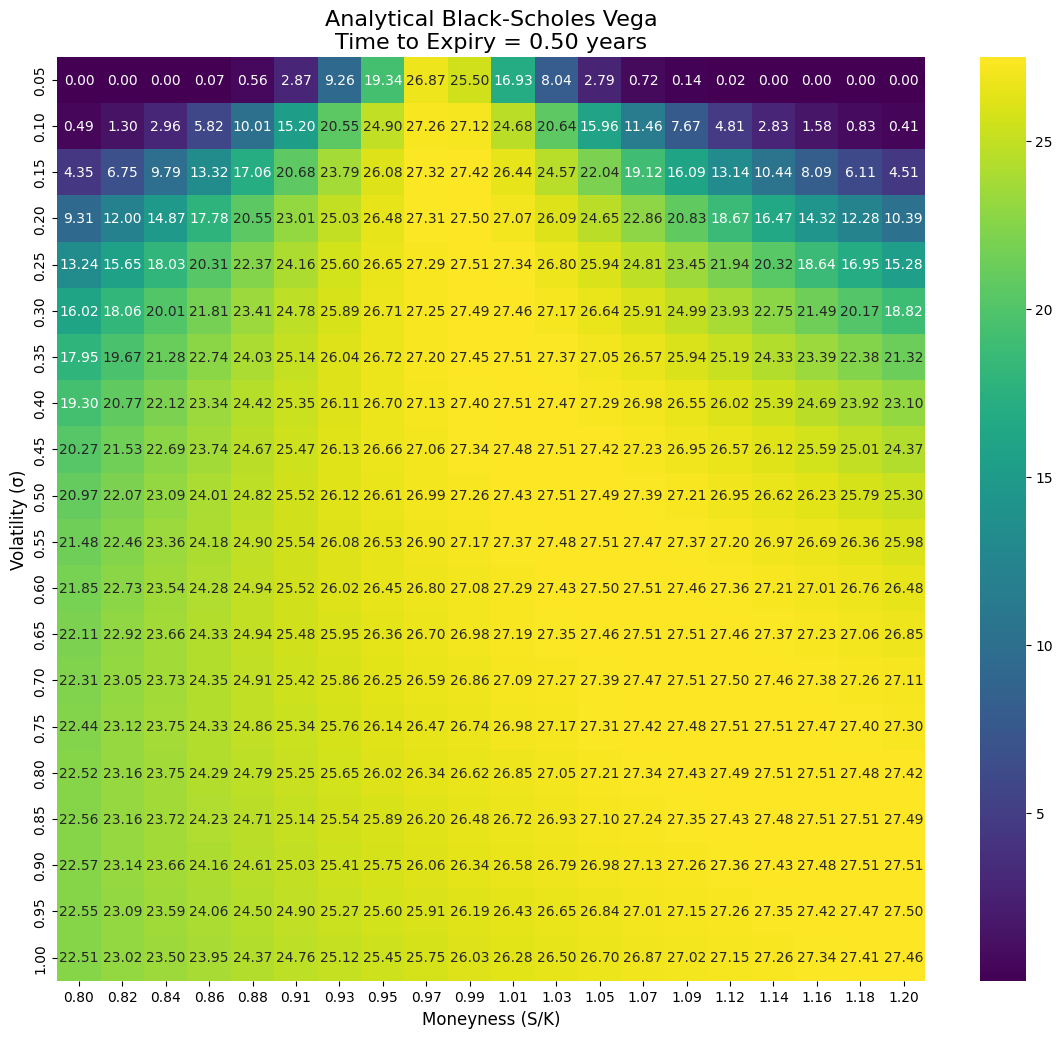


--- Generating Plot 2: Prediction Error per Moneyness Bin ---
(This may take a few minutes as it involves running many calibrations...)


Calibrating Test Points:   0%|          | 0/200 [00:00<?, ?it/s]

  Epoch 0/1500, Loss: 0.00000030, Current Sigma: 0.4000
  Epoch 500/1500, Loss: 0.00000013, Current Sigma: 0.3684
  Epoch 1000/1500, Loss: 0.00000013, Current Sigma: 0.3684
  Epoch 0/1500, Loss: 25.64250374, Current Sigma: 0.4000
  Epoch 500/1500, Loss: 12.04154396, Current Sigma: 0.5136
  Epoch 1000/1500, Loss: 2.64499092, Current Sigma: 0.6595
  Epoch 0/1500, Loss: 2.71076012, Current Sigma: 0.4000
  Epoch 500/1500, Loss: 0.91956323, Current Sigma: 0.3115
  Epoch 1000/1500, Loss: 0.16979641, Current Sigma: 0.2426
  Epoch 0/1500, Loss: 118.47002411, Current Sigma: 0.4000
  Epoch 500/1500, Loss: 93.02265167, Current Sigma: 0.5136
  Epoch 1000/1500, Loss: 64.20610046, Current Sigma: 0.6595
  Epoch 0/1500, Loss: 0.00062191, Current Sigma: 0.4000
  Epoch 500/1500, Loss: 0.00061925, Current Sigma: 0.5336
  Epoch 1000/1500, Loss: 0.00060706, Current Sigma: 0.8181
  Epoch 0/1500, Loss: 2.00056553, Current Sigma: 0.4000
  Epoch 500/1500, Loss: 0.00006664, Current Sigma: 0.3253
  Epoch 1000/15

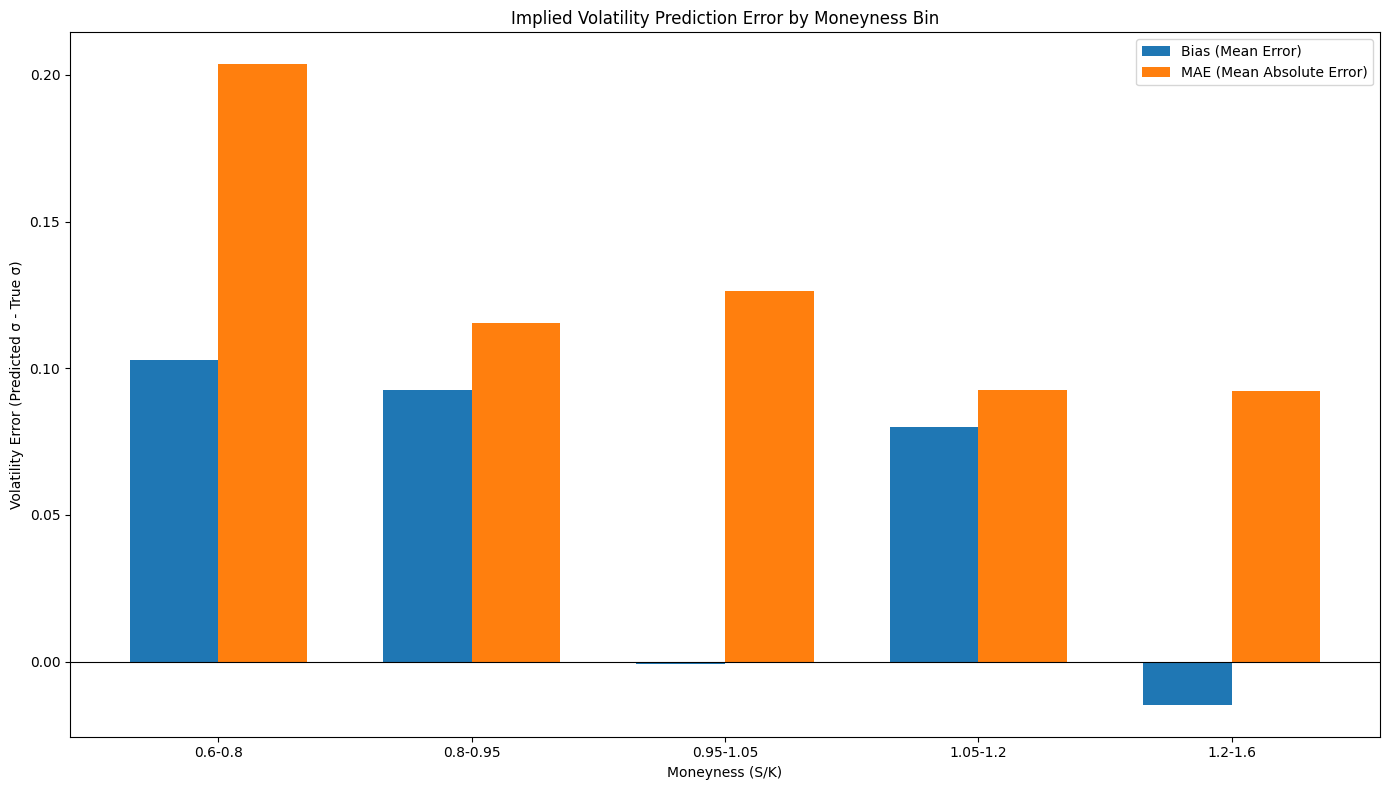